#### Dynamic Interruption of Nodes During Execution


Boileplate code

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
import warnings

warnings.filterwarnings("ignore")

load_dotenv()

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)
if google_llm:
    print("API loaded successfully")


API loaded successfully


Graph

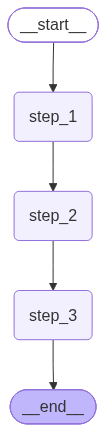

In [4]:
from IPython.display import display, Image
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt
from langgraph.graph import START,END, StateGraph

class State(TypedDict):
    input : str

def step_1(state : State) -> State:
    print("---Step 1---")
    return state

def step_2(state : State) -> State:
    print("---Step 2---")
    # optionally raising interruption based on certain condition only
    if len(state['input']) > 5:
        raise interrupt(f"Recieved input that is longer than 5 characters: {state["input"]}")
    return state

def step_3(state : State) -> State:
    print("---Step 3---")
    return state

builder = StateGraph(State)

builder.add_node("step_1",step_1)
builder.add_node("step_2",step_2)
builder.add_node("step_3",step_3)

builder.add_edge(START,"step_1")
builder.add_edge("step_1","step_2")
builder.add_edge("step_2","step_3")
builder.add_edge("step_3",END)

memory = MemorySaver()

graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))



In [5]:
initial_input = {"input":"Hello world..."}
thread_config = {"configurable":{"thread_id":"a"}}

# running graph until first interruption
for event in graph.stream(initial_input,thread_config,stream_mode="values"):
    print(event)

{'input': 'Hello world...'}
---Step 1---
{'input': 'Hello world...'}
---Step 2---
{'input': 'Hello world...', '__interrupt__': (Interrupt(value='Recieved input that is longer than 5 characters: Hello world...', id='f95d1299b61b083af1eb02c1d3464faa'),)}


In [6]:
state = graph.get_state(thread_config)
print(state.tasks)

(PregelTask(id='dc7ff089-0c22-d53e-c315-ff6775eba562', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(Interrupt(value='Recieved input that is longer than 5 characters: Hello world...', id='f95d1299b61b083af1eb02c1d3464faa'),), state=None, result=None),)


Unless we update/correct the state, it'll be interrupted forever even if we invoke/stream the graph with "None"

In [7]:
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'Hello world...'}
---Step 2---
{'input': 'Hello world...', '__interrupt__': (Interrupt(value='Recieved input that is longer than 5 characters: Hello world...', id='f95d1299b61b083af1eb02c1d3464faa'),)}


Only option - fix the State

In [9]:
graph.update_state(
    thread_config,
    {"input":"Hello"}
)
state = graph.get_state(thread_config).values
print(state)

{'input': 'Hello'}


Running the node after fixing the state

In [10]:
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'Hello'}
---Step 2---
{'input': 'Hello'}
---Step 3---
{'input': 'Hello'}
